In [2]:
# import the needed libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

%matplotlib inline

In [3]:
# Load the data into pandas DataFrame
path = "clean_df.csv"
df = pd.read_csv(path)
df.head()

,Unnamed: 0,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495
1,1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500
2,2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500
3,3,2,164.0,audi,gas,std,four,sedan,fwd,front,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950
4,4,2,164.0,audi,gas,std,four,sedan,4wd,front,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450


## 2. Analyzing Individual Feature Patterns Using Visualization

In [4]:
# list the data types for each column
print(df.dtypes)

Unnamed: 0             int64
symboling              int64
normalized-losses    float64
make                     str
fuel-type                str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                  int64
dtype: object


In [5]:
# Calculate the correlation between variables of type "int64" or "float64"
df.corr()

ValueError: could not convert string to float: 'alfa-romero'

In [6]:
# Drop the "Unnamed" column
df.drop("Unnamed: 0", inplace=True, axis=1)
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450


### 2.1 Continuous Numerical Variables
A great way to visualize them is by using scatterplots with fitted lines.

(0.0, 53354.3415472891)

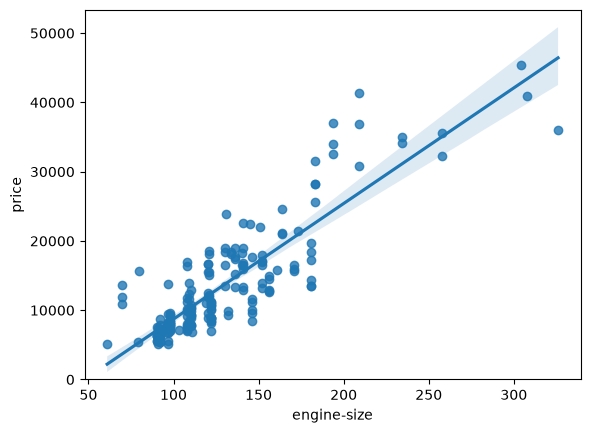

In [7]:
# Scatterplot of Engine-size and price
sns.regplot(x="engine-size", y="price", data=df)
plt.ylim(0,)

In [8]:
# Examine the correlation between engine-size and price
df[["engine-size", "price"]].corr()

,engine-size,price
engine-size,1.000000,0.872335
price,0.872335,1.000000


In [9]:
# Checkout the scatterplot for highway-L/100km and price
sns.regplot(x="highway-L/100km", y="price", data=df)
plt.ylim(0,)

KeyError: 'highway-L/100km'

In [10]:
# Check their correlation
df[["highway-L/100km", "price"]].corr()

KeyError: "['highway-L/100km'] not in index"

In [11]:
# Checkout the scatterplot for city-L/100km and price
sns.regplot(x="city-L/100km", y="price", data=df)
plt.ylim(0,)

KeyError: 'city-L/100km'

In [12]:
# Check their correlation
df[["city-L/100km", "price"]].corr()

KeyError: "['city-L/100km'] not in index"

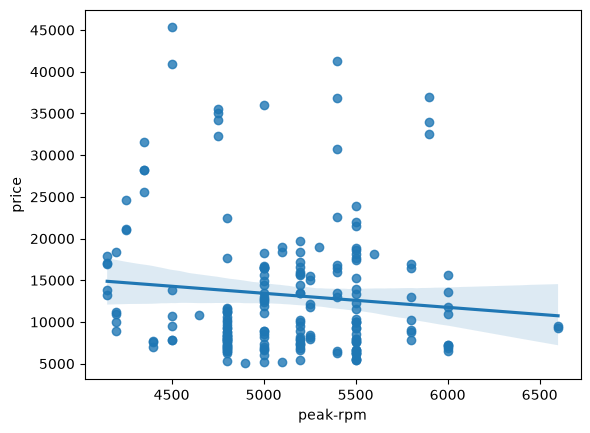

In [13]:
# Check out if peak-rpm is a predictor of price
sns.regplot(x="peak-rpm", y="price", data=df)
plt.show()

In [14]:
# Check their correlation
df[["peak-rpm", "price"]].corr()

,peak-rpm,price
peak-rpm,1.000000,-0.101649
price,-0.101649,1.000000


### 2.2 Categorical variables
A good way to visualize them is using boxplots

<Axes: xlabel='body-style', ylabel='price'>

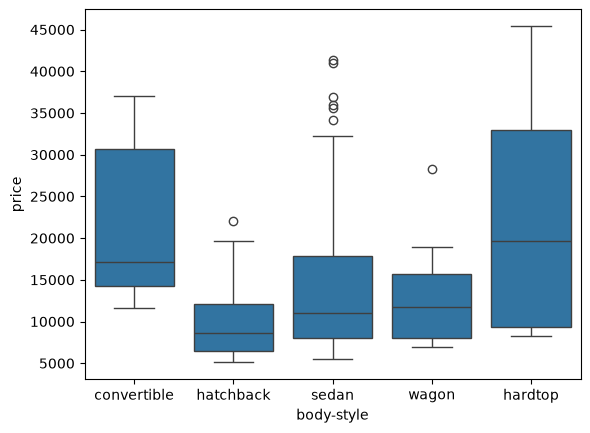

In [15]:
# Boxplot for body-type vs price
sns.boxplot(x="body-style", y="price", data=df)

<Axes: xlabel='engine-location', ylabel='price'>

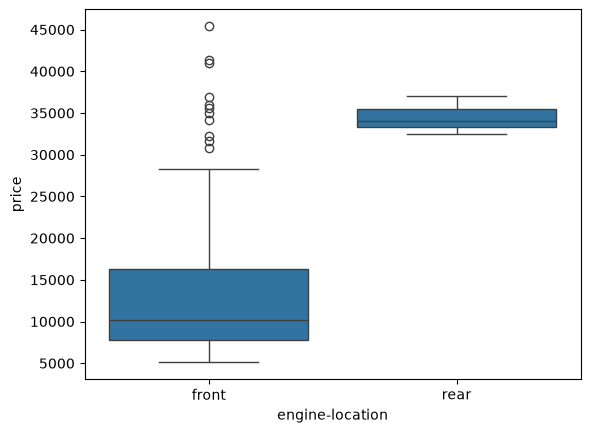

In [16]:
# Boxplot for engine-location vs price
sns.boxplot(x="engine-location", y="price", data=df)

<Axes: xlabel='drive-wheels', ylabel='price'>

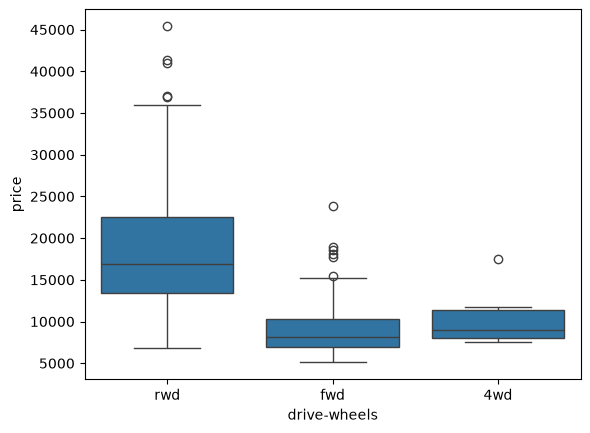

In [17]:
# Boxplot for drive-wheels vs price
sns.boxplot(x="drive-wheels", y="price", data=df)

## 3. Descriptive Statistical Analysis

In [18]:
# Apply decribe to variable of type "object" only
df.describe(include=['object'])

C:\Program Files\KMSpico\temp\ipykernel_8456\2936633325.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=['object'])


,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system
count,201,201,201,199,201,201,201,201,201,201
unique,22,2,2,2,5,3,2,6,7,8
top,toyota,gas,std,four,sedan,fwd,front,ohc,four,mpfi
freq,32,181,165,113,94,118,198,145,157,92


In [19]:
# Apply describe to continuous variables
df.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,201.000000,164.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,197.000000,197.000000,201.000000,199.000000,199.000000,201.000000,201.000000,201.000000
mean,0.840796,122.000000,98.797015,174.200995,65.889055,53.766667,2555.666667,126.875622,3.330711,3.256904,10.164279,103.396985,5117.587940,25.179104,30.686567,13207.129353
std,1.254802,35.442168,6.066366,12.322175,2.101471,2.447822,517.296727,41.546834,0.270793,0.319256,4.004965,37.553843,480.521824,6.423220,6.815150,7947.066342
min,-2.000000,65.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.000000,94.500000,166.800000,64.100000,52.000000,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,115.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,150.000000,102.400000,183.500000,66.600000,55.500000,2926.000000,141.000000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000


In [20]:
df.describe(include=['int64'])

,symboling,curb-weight,engine-size,city-mpg,highway-mpg,price
count,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,2555.666667,126.875622,25.179104,30.686567,13207.129353
std,1.254802,517.296727,41.546834,6.423220,6.815150,7947.066342
min,-2.000000,1488.000000,61.000000,13.000000,16.000000,5118.000000
25%,0.000000,2169.000000,98.000000,19.000000,25.000000,7775.000000
50%,1.000000,2414.000000,120.000000,24.000000,30.000000,10295.000000
75%,2.000000,2926.000000,141.000000,30.000000,34.000000,16500.000000
max,3.000000,4066.000000,326.000000,49.000000,54.000000,45400.000000


### 3.1 Value Counts
A good way of understanding how many units of each characteristic/variable we have. The pandas' "value_counts" method only works on pandas series and not dataframes. Single square parenthesis ([]) are therefore used and not double parenthesis ([[]]).

In [21]:
df['drive-wheels'].value_counts()

drive-wheels
fwd    118
rwd     75
4wd      8
Name: count, dtype: int64

In [22]:
# to convert the series to a dataframe, use:
df['drive-wheels'].value_counts().to_frame()

,count
drive-wheels,
fwd,118
rwd,75
4wd,8


In [23]:
# Repeat the process and save the results to"drive-wheel-counts" and rename the 'drive-wheels' column to "value-counts"
drive_wheel_counts = df["drive-wheels"].value_counts().to_frame()
drive_wheel_counts.rename(columns={'drive-wheels':'value_counts'}, inplace=True)
drive_wheel_counts

,count
drive-wheels,
fwd,118
rwd,75
4wd,8


In [24]:
# Now rename the index to "drive-wheels"
drive_wheel_counts.index.names = ["drive-wheels"]
drive_wheel_counts

,count
drive-wheels,
fwd,118
rwd,75
4wd,8


In [25]:
# Repeat the same for the variable "engine-location"
engine_location_counts=df['engine-location'].value_counts().to_frame()
engine_location_counts.rename(columns={'engine-location':'value_counts'}, inplace=True)
engine_location_counts.index.names = ['engine-location']
engine_location_counts

,count
engine-location,
front,198
rear,3


## 4. Basics of Grouping
The "groupby" method groups data by different categories

In [26]:
df['drive-wheels'].unique()

<StringArray>
['rwd', 'fwd', '4wd']
Length: 3, dtype: str

In [27]:
# Group several variables and calculate average for each category
df_group_one = df[['drive-wheels', 'body-style', 'price']]
df_group_one = df_group_one.groupby(['drive-wheels'],as_index=False).mean()
df_group_one

TypeError: dtype 'str' does not support operation 'mean'

In [28]:
# We can also groupby multiple variables
df_gptest     = df[['drive-wheels', 'body-style', 'price']]
grouped_test1 = df_gptest.groupby(['drive-wheels', 'body-style'], as_index=False).mean()
grouped_test1

,drive-wheels,body-style,price
0,4wd,hatchback,7603.000000
1,4wd,sedan,12647.333333
2,4wd,wagon,9095.750000
3,fwd,convertible,11595.000000
4,fwd,hardtop,8249.000000
5,fwd,hatchback,8396.387755
6,fwd,sedan,9811.800000
7,fwd,wagon,9997.333333
8,rwd,convertible,23949.600000
9,rwd,hardtop,24202.714286


In [29]:
# It is nicer to visualize the groouped data using a pivot table
grouped_pivot = grouped_test1.pivot(index='drive-wheels', columns='body-style')
grouped_pivot

price                                            \
body-style   convertible       hardtop     hatchback         sedan   
drive-wheels                                                         
4wd                  NaN           NaN   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body-style           wagon  
drive-wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

In [30]:
# Let's fill the missing data with 0
grouped_pivot = grouped_pivot.fillna(0)
grouped_pivot

price                                            \
body-style   convertible       hardtop     hatchback         sedan   
drive-wheels                                                         
4wd                  0.0      0.000000   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body-style           wagon  
drive-wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

In [31]:
# Use the "groupby" function to find the average "price" of each car based on "body_style"
df_gp = df[["body-style", "price"]]
df_group_two = df_gp.groupby(["body-style"], as_index=False).mean()
df_group_two

,body-style,price
0,convertible,21890.500000
1,hardtop,22208.500000
2,hatchback,9957.441176
3,sedan,14459.755319
4,wagon,12371.960000


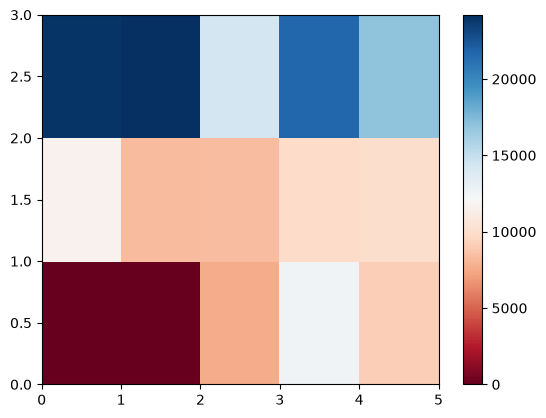

In [32]:
#Use heat map to visualize relationship between Body style and price
plt.pcolor(grouped_pivot, cmap='RdBu')
plt.colorbar()
plt.show()

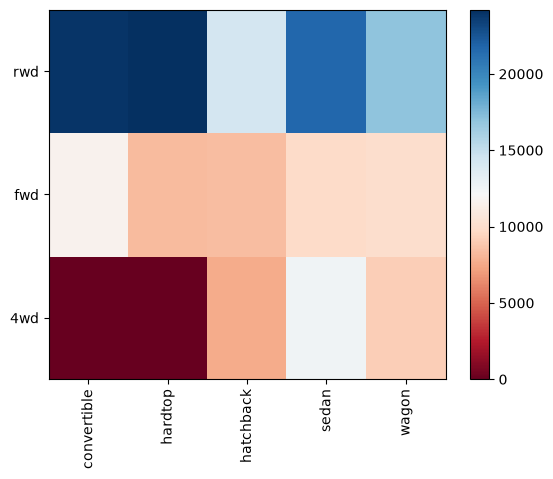

In [34]:
# Change the labels
fig, ax = plt.subplots()
im = ax.pcolor(grouped_pivot, cmap='RdBu')

#label names
row_labels= grouped_pivot.columns.levels[1]
col_labels= grouped_pivot.index

#move ticks and labels to the center
ax.set_xticks(np.arange(grouped_pivot.shape[1]) + 0.5, minor=False)
ax.set_yticks(np.arange(grouped_pivot.shape[0]) + 0.5, minor=False)

# insert labels
ax.set_xticklabels(row_labels, minor=False)
ax.set_yticklabels(col_labels, minor=False)

# rotate label if too long
plt.xticks(rotation=90)

fig.colorbar(im)
plt.show()

## 5. Correlation and Causation
<p><b>Correlation</b>: a measure of the extent of interdependence between variables.
<p><b>Causation</b>: the relationship between cause and effect between two variables.
<p><b>P-vlaue</b>: is the probability value that the correlation between two variables is statistically significant.

In [35]:
# Wheel-Base vs price
pearson_coef, p_value = stats.pearsonr(df['wheel-base'], df['price'])
print(pearson_coef, p_value)

0.584641822265508 8.076488270732847e-20


<h4> Conclusion:</h4>
<p>Since the p-value is $<$ 0.001, the correlation between wheel-base and price is statistically significant, although the linear relationship isn't extremely strong (~0.585).</p>

In [36]:
# Horsepower vs. Price
pearson_coef, p_value = stats.pearsonr(df['horsepower'], df['price'])
print(pearson_coef, p_value)

nan nan


<h4> Conclusion:</h4>
<p>Since the p-value is $<$ 0.001, the correlation between horsepower and price is statistically significant, and the linear relationship is quite strong (~0.809).</p>

## 6. ANOVA
<p>Analysis of Variance is used to determine whether there is significant differences between the means of two or more groups. It returns:</p>
<p><b>F-test score</b> : A larger F-score means there is a larger difference between the means.</p>
<p><b>P-value</b> : Tells how statistically significant the calculated score value is.</p>

<h3>Example: Drive Wheels</h3>
Since ANOVA analyses the difference between different groups of the same variable, the groupby function will come in handy.

In [37]:
# Check if different types of drive wheels impact price
grouped_test2 = df_gptest[['drive-wheels','price']].groupby(['drive-wheels'])
grouped_test2.head()

,drive-wheels,price
0,rwd,13495
1,rwd,16500
2,rwd,16500
3,fwd,13950
4,4wd,17450
5,fwd,15250
6,fwd,17710
7,fwd,18920
8,fwd,23875
9,rwd,16430


In [38]:
df_gptest

,drive-wheels,body-style,price
0,rwd,convertible,13495
1,rwd,convertible,16500
2,rwd,hatchback,16500
3,fwd,sedan,13950
4,4wd,sedan,17450
...,...,...,...
196,rwd,sedan,16845
197,rwd,sedan,19045
198,rwd,sedan,21485
199,rwd,sedan,22470


In [39]:
grouped_test2.get_group('4wd')['price']

KeyError: '4wd'

In [40]:
# Obtain the F-score and P-value
f_val, p_val = stats.f_oneway(grouped_test2.get_group('fwd')['price'], grouped_test2.get_group('rwd')['price'], grouped_test2.get_group('4wd')['price'])
print("ANOVA results: F = ", f_val, ", P = ", p_val)

KeyError: 'fwd'

In [41]:
# Examine the different wheels separately: fwd and rwd
f_val, p_val = stats.f_oneway(grouped_test2.get_group('fwd')['price'], grouped_test2.get_group('rwd')['price'])
print("ANOVA results: F = ", f_val, ", P = ", p_val)

KeyError: 'fwd'

In [42]:
# Examine the different wheels separately: 4wd and rwd
f_val, p_val = stats.f_oneway(grouped_test2.get_group('4wd')['price'], grouped_test2.get_group('rwd')['price'])
print("ANOVA results: F = ", f_val, ", P = ", p_val)

KeyError: '4wd'

In [43]:
# Examine the different wheels separately: fwd and 4wd
f_val, p_val = stats.f_oneway(grouped_test2.get_group('fwd')['price'], grouped_test2.get_group('4wd')['price'])
print("ANOVA results: F = ", f_val, ", P = ", p_val)

KeyError: 'fwd'